In [1]:
import numpy as np
import pandas as pd
from SWMM import SWMM_ENV as SWMM_ENV
from HC import HC as HC
import datetime
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import os
import yaml

import datetime

# from MPC import pso
import pyswmm
from swmm_api.input_file import read_inp_file
from pyswmm import Simulation,Links,Nodes,RainGages,SystemStats
from swmm_api.input_file.sections.others import TimeseriesData
from swmm_api.input_file.sections import Control
from swmm_api.input_file.section_labels import TIMESERIES, CONTROLS
from swmm_api import read_rpt_file, SwmmReport

from scipy import stats
import math

from matplotlib.cm import get_cmap
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors

E:\Anaconda\envs\drainage\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from matplotlib import rcParams

config = {
            "font.family": 'serif',
            "font.size": 22,                 
            "axes.titlesize": 25,            
            "axes.labelsize": 24,            
            "xtick.labelsize": 22,           
            "ytick.labelsize": 22,            
            "legend.fontsize": 22,            
            "pdf.fonttype": 42,              
            "ps.fonttype": 42,
            "mathtext.fontset": 'stix',
            "font.serif": ['Times New Roman'],
            'axes.unicode_minus': False
         }
rcParams.update(config)

# Rainfalls

In [3]:
raindata = np.load('rainfall/training_raindata.npy').tolist()

In [4]:
rainreal = np.load('rainfall\\real_raindata.npy').tolist()

In [5]:
rainreal = [
    [
        [time, str(float(rain) * 5)]
        for time, rain in event
    ]
    for event in rainreal
]

# Load simulation results

In [6]:
r_base = np.load('./results/HC.npy',allow_pickle=True).tolist()
r_GI = np.load('./results/HC_GI.npy',allow_pickle=True).tolist()

r_HC = np.load('./results/HC_GI_true.npy',allow_pickle=True).tolist()
r_MPC = np.load('./results/MPC_GI.npy',allow_pickle=True).tolist()
r_DQN = np.load('./results/DQN3_GI_new.npy',allow_pickle=True).tolist()
r_DQN_o = np.load('./results/DQN3_GI.npy',allow_pickle=True).tolist()
r_DQN_train_GI = np.load('./results/DQN3_train_GI.npy',allow_pickle=True).tolist()

In [7]:
r_base_real = np.load('./results_m_real/HC.npy',allow_pickle=True).tolist()
r_GI_real = np.load('./results_m_real/HC_GI.npy',allow_pickle=True).tolist()

r_HC_real = np.load('./results_m_real/HC_GI_true.npy',allow_pickle=True).tolist()
r_MPC_real = np.load('./results_m_real/MPC_GI.npy',allow_pickle=True).tolist()
r_DQN_real = np.load('./results_m_real/DQN3_GI_new.npy',allow_pickle=True).tolist()
r_DQN_o_real = np.load('./results_m_real/DQN3_GI.npy',allow_pickle=True).tolist()
r_DQN_train_GI_real = np.load('./results_m_real/DQN3_train_GI.npy',allow_pickle=True).tolist()

In [8]:
# print(r_MPC_real)

In [9]:
num_rainfalls = 30 # total: 1000
start_idx = 50
one_step = 5 # 300s = 5min

# delta_1 & delta_2

In [10]:
delta_1_results = []
for i in range(num_rainfalls):
    k = str(i + start_idx)
    base_inflow = np.array(r_base['rainfall' + k]['env4']['inflow'][2:]) / 1000.0
    gi_inflow   = np.array(r_GI['rainfall' + k]['env3']['inflow'][2:]) / 1000.0
    delta_1 = np.sum(base_inflow - gi_inflow)
    delta_1_results.append(delta_1)
delta_1_results = np.array(delta_1_results)

In [11]:
def delta2_vs_strategy(strategy_record, rainfall_key, flooding_path, cso_path):
    base_f = (np.array(r_base[rainfall_key]['env4']['flooding'][2:]) / 1000.0 +
              np.array(r_base[rainfall_key]['env4']['CSO'][2:])      / 1000.0)
    f = strategy_record[rainfall_key]
    for k in flooding_path:
        f = f[k]
    c = strategy_record[rainfall_key]
    for k in cso_path:
        c = c[k]
    strat_f = (np.array(f)[2:] / 1000.0 + np.array(c)[2:] / 1000.0)
    return float(np.sum(base_f - strat_f))

In [12]:
delta_2_results_DRL_new = []
delta_2_results_DRL_train_GI = []
delta_2_results_DRL = []
delta_2_results_HC = []
delta_2_results_MPC = []
delta_2_results_GI = [] 

for i in range(num_rainfalls):
    k = str(i + start_idx)
    rk = 'rainfall' + k

    
    delta_2_results_DRL_new.append(
        delta2_vs_strategy(r_DQN, rk, ['env_new', 'flooding'], ['env_new', 'CSO'])
    )
  
    delta_2_results_DRL_train_GI.append(
        delta2_vs_strategy(r_DQN_train_GI, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    )

    delta_2_results_HC.append(
        delta2_vs_strategy(r_HC, rk, ['env5', 'flooding'], ['env5', 'CSO'])
    )
 
    delta_2_results_MPC.append(
        delta2_vs_strategy(r_MPC, rk, ['flooding'], ['CSO'])
    )
 
    delta_2_results_DRL.append(
        delta2_vs_strategy(r_DQN_o, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    )

    delta_2_results_GI.append(
        delta2_vs_strategy(r_GI, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    )

delta_2_results_DRL_new = np.array(delta_2_results_DRL_new)
delta_2_results_DRL_train_GI = np.array(delta_2_results_DRL_train_GI)
delta_2_results_HC = np.array(delta_2_results_HC)
delta_2_results_MPC = np.array(delta_2_results_MPC)
delta_2_results_DRL = np.array(delta_2_results_DRL)
delta_2_results_GI = np.array(delta_2_results_GI)

# Regression plot

In [13]:
specs = [
    ('DRL-GCI', '#006837', '*', 550),
    ('DRL-GIenv', '#31a354', 'P', 300),
    ('DRL-Base', '#a1d99b', 'o', 250),
    ('MPC', '#41b6c4', 'D', 200),
    ('HC', '#6baed6', '^', 250),
    ('GI-Only', '#969696', 's', 200)
]

scatter_edge = 'white'
scatter_edge_lw = 0.8
# scatter_size = 200  

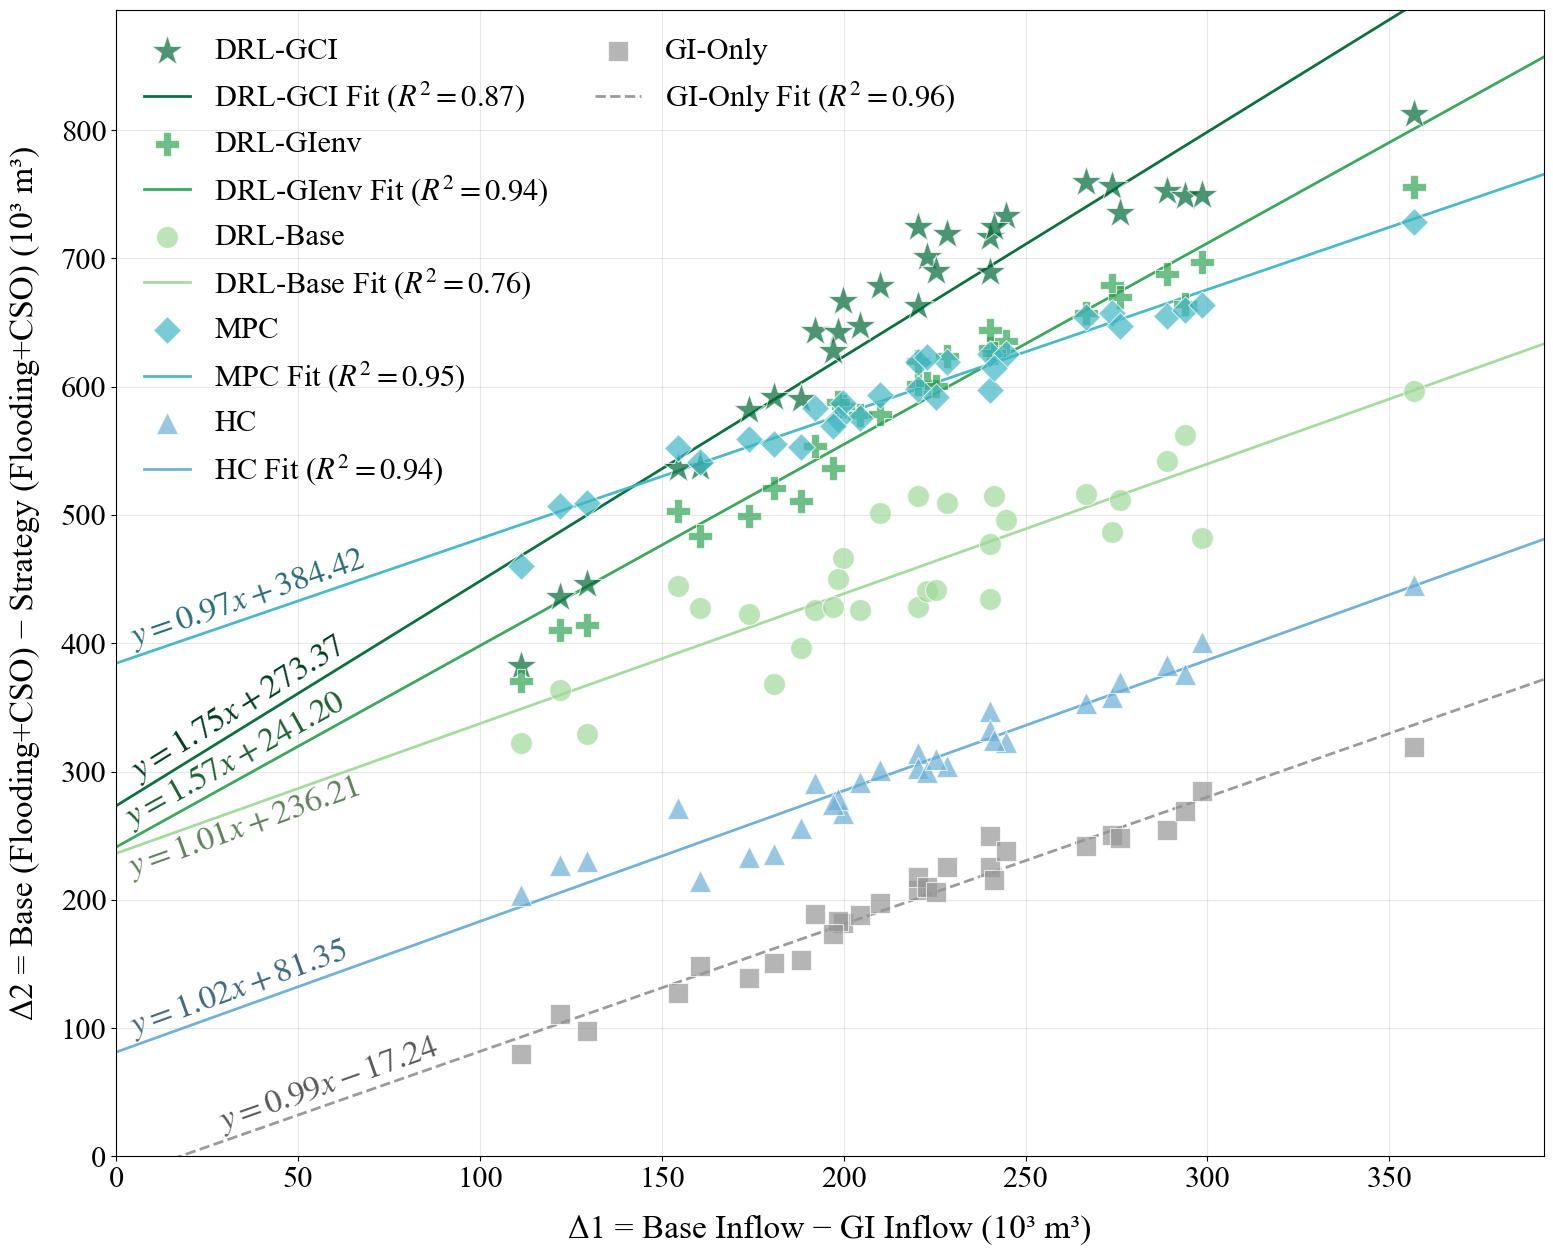

In [14]:
fig, ax = plt.subplots(figsize=(16, 13))

def add_reg_line(ax, x, y, color, label_prefix, linestyle='-'):
    if np.all(~np.isfinite(x)) or np.all(~np.isfinite(y)) or len(x) < 2:
        return None, None, None
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return None, None, None
    slope, intercept, r_val, p_val, std_err = stats.linregress(x[mask], y[mask])

    x_line = np.array([0, max(x[mask])*1.1 if np.max(x[mask]) > 0 else 1.0])
    y_line = slope * x_line + intercept
    r2 = r_val**2

    line_label = f"{label_prefix} Fit ($R^2={r2:.2f}$)"
    ax.plot(x_line, y_line, linestyle=linestyle, color=color, linewidth=2, alpha=0.95, zorder=2, label=line_label)

    c_rgb = mcolors.to_rgb(color)
    dark_color = tuple([max(0, val * 0.6) for val in c_rgb])

    annotation = {
        'x_start':   x_line[0],   'y_start':   y_line[0],
        'x_end':     x_line[-1],  'y_end':     y_line[-1],
        'slope':     slope,        
        'intercept': intercept,   
        'equation': (
            f"$y = {slope:.2f}x + {intercept:.2f}$"
            if intercept >= 0
            else f"$y = {slope:.2f}x - {abs(intercept):.2f}$"
        ),
        'color':     dark_color,
        'x_shift':   0,            
        'above':     False,       
    }

    return slope, r2, annotation

reg_summaries = []
pending_annotations = []

label_settings = {
    'DRL-GCI':   {'x_shift': -65, 'above': True},
    'DRL-GIenv': {'x_shift': -65, 'above': True},
    'DRL-Base':  {'x_shift': -65, 'above': False},
    'HC':        {'x_shift': -65, 'above': True},
    'MPC':       {'x_shift': -70, 'above': True},
    'GI-Only':   {'x_shift': -90, 'above': True},
}

# Scatter
for label, color, marker, scatter_size in specs:
    yvals = {
        'DRL-GCI':   delta_2_results_DRL_new,
        'DRL-GIenv': delta_2_results_DRL_train_GI,
        'DRL-Base':  delta_2_results_DRL,
        'HC':        delta_2_results_HC,
        'MPC':       delta_2_results_MPC,
        'GI-Only':   delta_2_results_GI,
    }[label]

    sc = ax.scatter(
        delta_1_results, yvals,
        c=color, marker=marker, s=scatter_size, alpha=0.7,
        edgecolors=scatter_edge, linewidth=scatter_edge_lw,
        label=label, zorder=3
    )
    linestyle = '--' if label == 'GI-Only' else '-'
    slope, r2, ann = add_reg_line(
        ax, np.array(delta_1_results), np.array(yvals),
        color, label, linestyle=linestyle
    )
    if ann is not None:
        ann['x_shift'] = label_settings[label]['x_shift'] 
        ann['above']   = label_settings[label]['above']
        pending_annotations.append(ann)
    reg_summaries.append((label, slope, r2))

ax.set_xlabel('Δ1 = Base Inflow − GI Inflow (10³ m³)', labelpad=15)
ax.set_ylabel('Δ2 = Base (Flooding+CSO) − Strategy (Flooding+CSO) (10³ m³)', labelpad=15)
# ax.set_title(f'Δ2 vs Δ1 across {num_rainfalls} rainfall events')
ax.grid(True, alpha=0.3)

x_max = max(1e-9, np.nanmax(delta_1_results)) * 1.1
y_max = max(
    np.nanmax(delta_2_results_DRL_new),
    np.nanmax(delta_2_results_DRL_train_GI),
    np.nanmax(delta_2_results_DRL),
    np.nanmax(delta_2_results_HC),
    np.nanmax(delta_2_results_MPC),
    np.nanmax(delta_2_results_GI),
) * 1.1
ax.set_xlim(0, x_max if x_max > 0 else 1.0)
ax.set_ylim(0, y_max if y_max > 0 else 1.0)

fig.canvas.draw()

gap_pixels = 1  

for ann in pending_annotations:
    x_text = ann['x_start'] - ann['x_shift']
    y_text = ann['slope'] * x_text + ann['intercept']

    p1 = ax.transData.transform((ann['x_start'], ann['y_start']))
    p2 = ax.transData.transform((ann['x_end'],   ann['y_end']))
    angle     = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))
    angle_rad = np.radians(angle)

    if ann['above']:
        dx_pixel = -np.sin(angle_rad) * gap_pixels   
        dy_pixel =  np.cos(angle_rad) * gap_pixels
        va = 'bottom' 
    else:
        dx_pixel =  np.sin(angle_rad) * gap_pixels   
        dy_pixel = -np.cos(angle_rad) * gap_pixels
        va = 'top'    

    x_disp, y_disp = ax.transData.transform((x_text, y_text))
    x_final, y_final = ax.transData.inverted().transform(
        (x_disp + dx_pixel, y_disp + dy_pixel)
    )

    ax.text(x_final, y_final,
            ann['equation'],
            color=ann['color'], fontsize=24, fontweight='bold',
            rotation=angle,
            rotation_mode='anchor',  
            va=va,                
            ha='right',        
            zorder=4)

# ax.legend(loc='upper left', ncol=1, frameon=False)
handles, labels = ax.get_legend_handles_labels()

# Force column break at HC 
hc_idx = labels.index('GI-Only')        
n_col1 = hc_idx                 
n_col2 = len(handles) - hc_idx   
n_pad  = max(0, n_col1 - n_col2)   

blank = plt.Line2D([], [], linestyle='none')
handles = list(handles) + [blank] * n_pad
labels  = list(labels)  + ['']    * n_pad


ax.legend(handles, labels,
          loc='upper left',
          ncol=2,            
          frameon=False,
          columnspacing=1.5,  
          handlelength=1.5)

plt.tight_layout()

# plt.savefig("results_regression_all.png", dpi=300, bbox_inches="tight")
plt.show()

# Without MPC

# Process

In [15]:
n_pick = 4

peak_values = []
for i in range(num_rainfalls):
    i += start_idx
    rain_event = raindata[i]
    event_rain_values = [float(v[1]) for v in rain_event]  
    peak = max(event_rain_values) if len(event_rain_values) > 0 else 0.0
    peak_values.append(peak)

peak_values = np.array(peak_values)
sorted_indices = np.argsort(peak_values) 

if n_pick == 1:
    chosen_local_idx = [len(sorted_indices)//2]
else:
    chosen_local_idx = np.linspace(0, len(sorted_indices)-1, n_pick).round().astype(int)

chosen_indices = sorted_indices[chosen_local_idx] 
chosen_events = [start_idx + int(i) for i in chosen_indices]

print("Selected events by peak gradient:", chosen_events)
print("Their peak intensities:", [float(peak_values[i]) for i in chosen_indices])

Selected events by peak gradient: [70, 64, 67, 51]
Their peak intensities: [81.38139521835302, 136.99042512240572, 161.3605100623962, 228.33281936149768]


In [16]:
# real rainfalls
chosen_events.append(0)
chosen_events.append(1)
chosen_events.append(2)
chosen_events.append(3)

In [17]:
print(chosen_events)

[70, 64, 67, 51, 0, 1, 2, 3]


In [18]:
def get_series(record, rainfall_key, path_list):
    x = record[rainfall_key]
    for k in path_list:
        x = x[k]
    return np.array(x, dtype=float)[2:] / 1000.0  

def inflow_series_base_and_gi(k_str, if_real = False):
    base_in = get_series(r_base if not if_real else r_base_real, k_str, ['env4', 'inflow'])
    gi_in   = get_series(r_GI if not if_real else r_GI_real,   k_str, ['env3', 'inflow'])
    return base_in, gi_in

def flood_cso_series(record, rainfall_key, flood_path, cso_path):
    f = get_series(record, rainfall_key, flood_path)
    c = get_series(record, rainfall_key, cso_path)
    return f + c  

def safe_ratio_num_den(num, den):
        num = np.asarray(num, dtype=float)
        den = np.asarray(den, dtype=float)
        return np.divide(num, den, out=np.zeros_like(num), where=(den != 0))

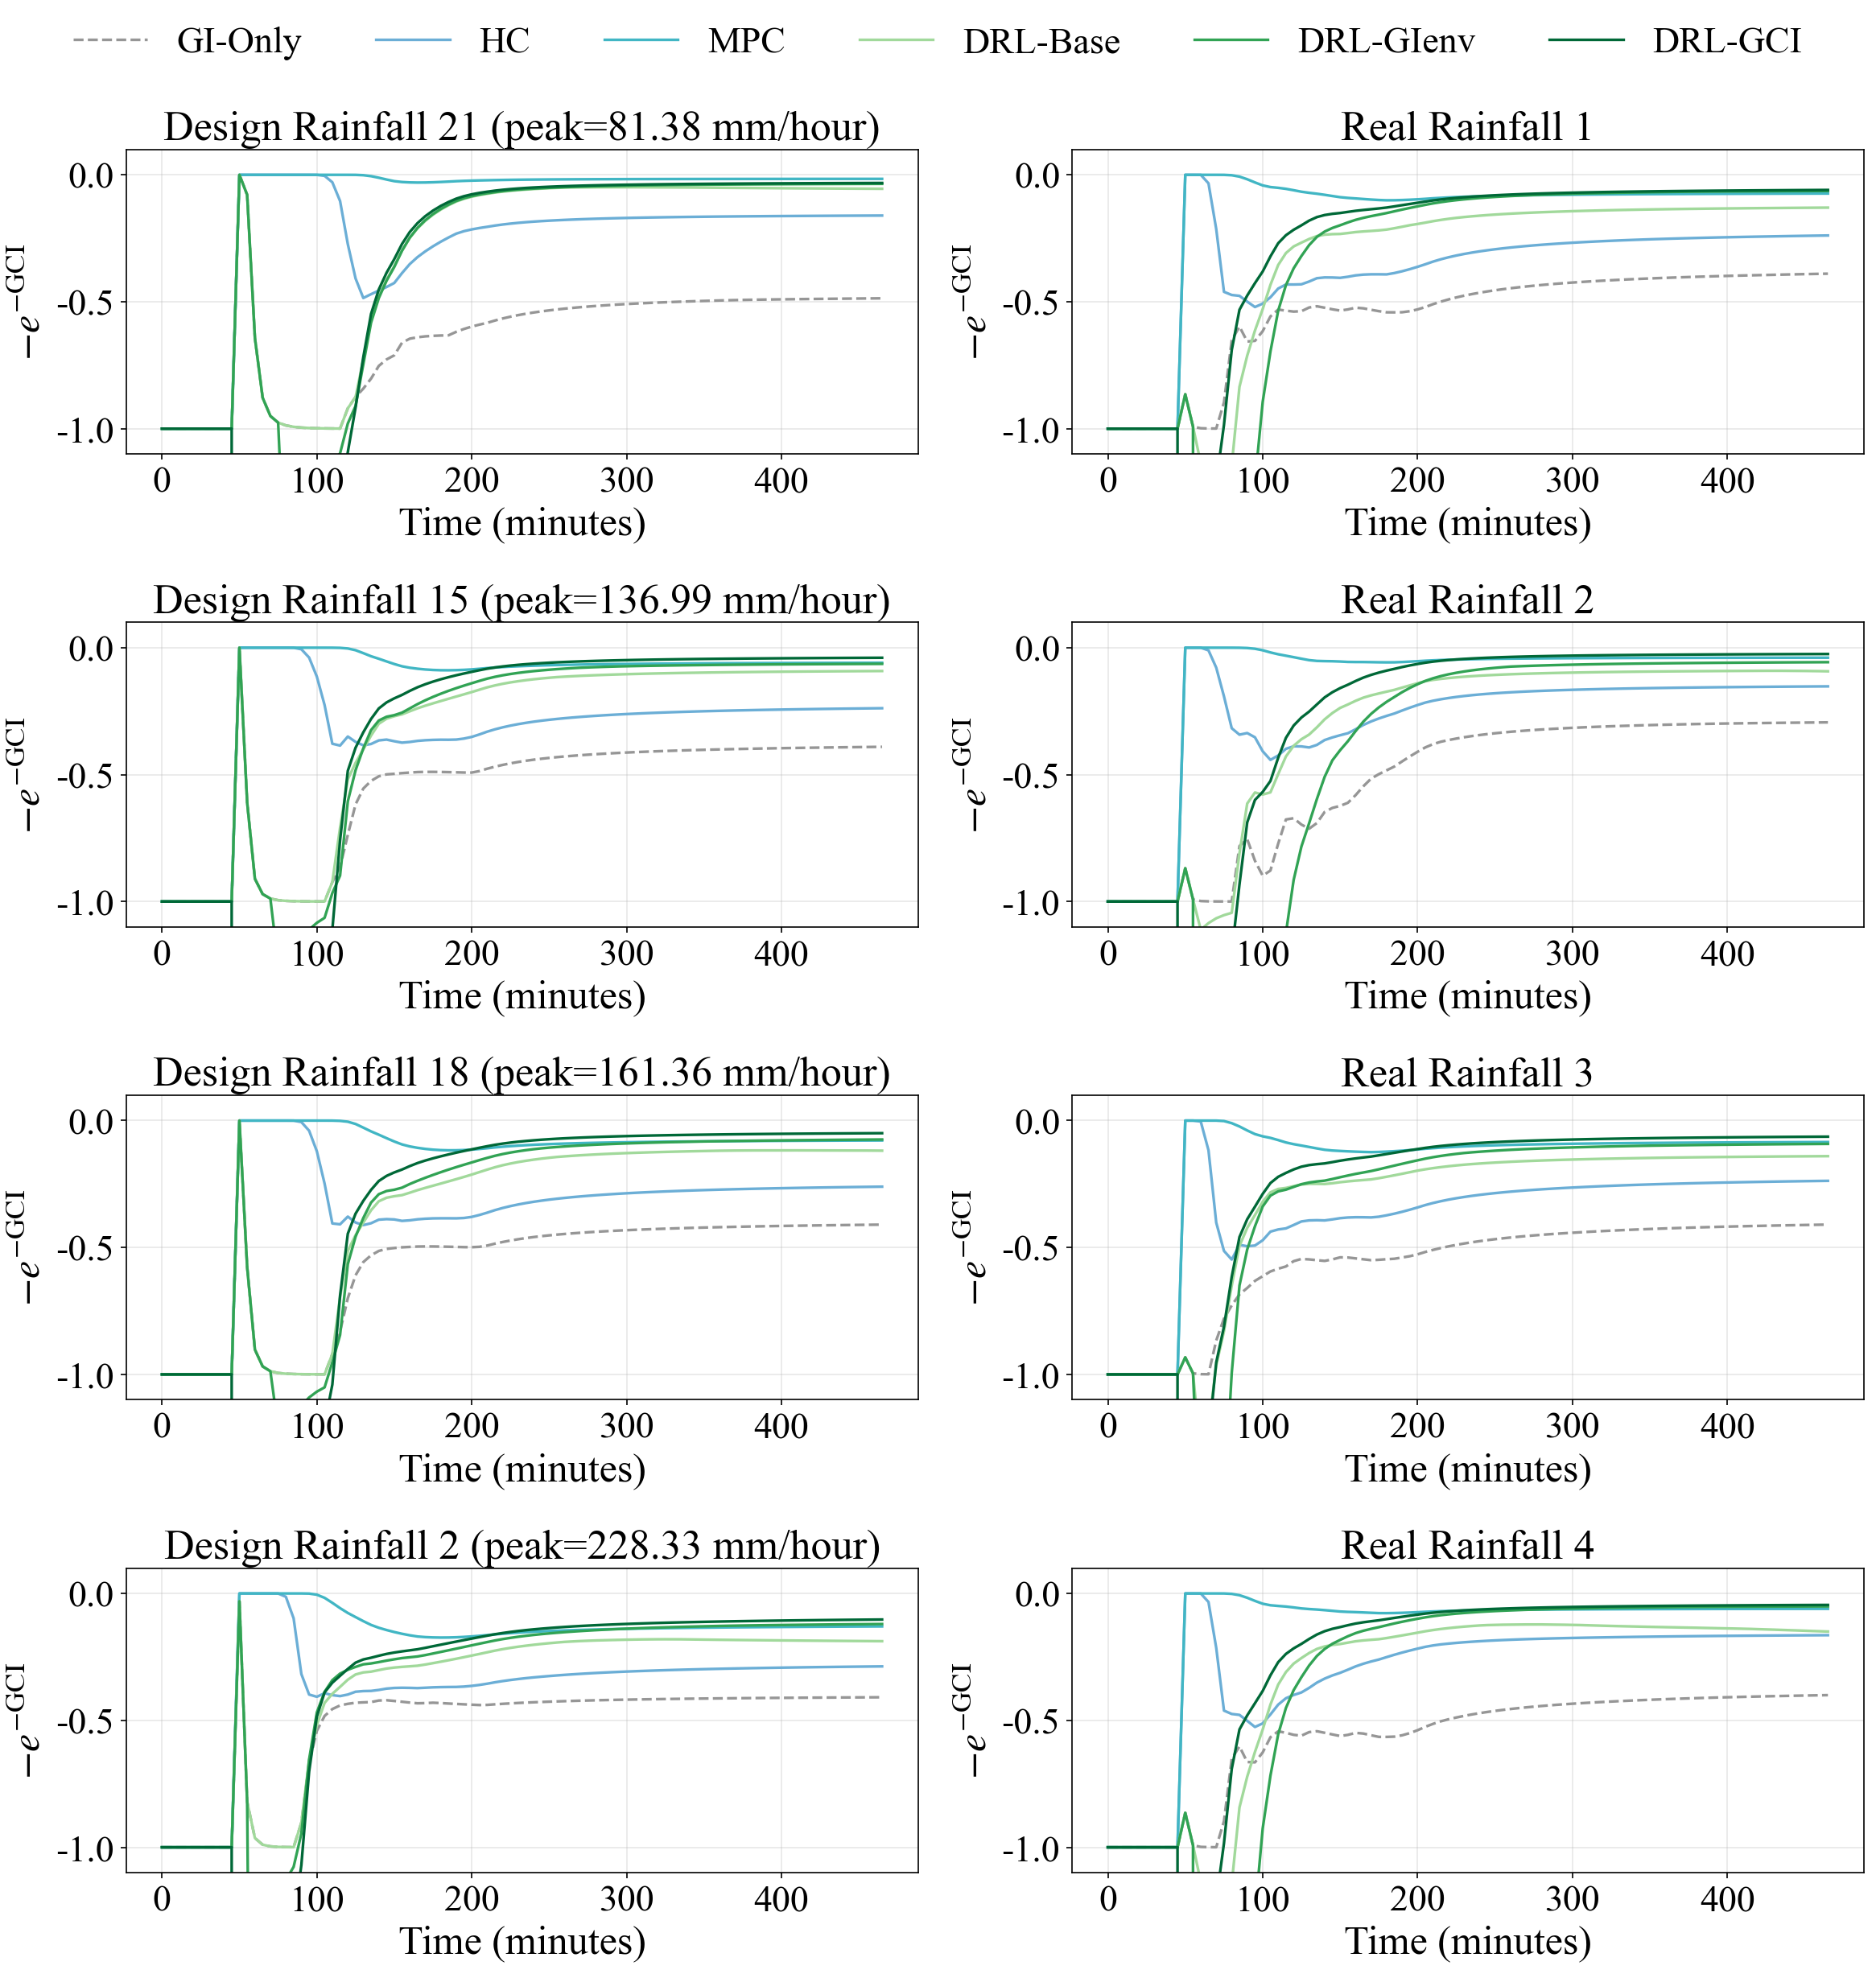

In [19]:
n_pick = len(chosen_events)
n_col = 2
n_row = math.ceil(n_pick / n_col)
figsize = (n_col * 8, n_row * 4)
dpi = 150

# color
color_GI = "#969696" 
color_HC = "#6baed6" 
color_DQN_o = "#a1d99b" 
color_DQN_new = "#006837" 
color_DQN_train_GI = "#31a354" 
color_MPC = "#41b6c4"

fig, ax = plt.subplots(n_row, n_col, figsize=figsize, dpi=dpi, squeeze=False)

handles_labels_collected = False
handles, labels = None, None

for i, ev in enumerate(chosen_events):
    k = str(ev)
    rk = 'rainfall' + k 
    col = i // n_row
    row = i % n_row

    # Cumulative Δ1
    base_in, gi_in = inflow_series_base_and_gi(rk, if_real = True if i>=4 else False)
    delta1_cum = np.cumsum(base_in - gi_in)

    base_fc = flood_cso_series(r_base if i<4 else r_base_real, rk, ['env4', 'flooding'], ['env4', 'CSO'])
    gi_fc = flood_cso_series(r_GI if i<4 else r_GI_real, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    dqnN_fc = flood_cso_series(r_DQN if i<4 else r_DQN_real, rk, ['env_new', 'flooding'], ['env_new', 'CSO'])
    dqnO_fc = flood_cso_series(r_DQN_o if i<4 else r_DQN_o_real, rk, ['env3', 'flooding'], ['env3', 'CSO'])  
    dqnG_fc = flood_cso_series(r_DQN_train_GI if i<4 else r_DQN_train_GI_real, rk, ['env3', 'flooding'], ['env3', 'CSO'])  
    hc_fc = flood_cso_series(r_HC if i<4 else r_HC_real, rk, ['env5', 'flooding'], ['env5', 'CSO'])
    mpc_fc = flood_cso_series(r_MPC if i<4 else r_MPC_real, rk, ['flooding'], ['CSO'])

    # Cumulative Δ2
    delta2_gi_cum = np.cumsum(base_fc - gi_fc)
    delta2_dqnN_cum = np.cumsum(base_fc - dqnN_fc)
    delta2_dqnO_cum = np.cumsum(base_fc - dqnO_fc)
    delta2_dqnG_cum = np.cumsum(base_fc - dqnG_fc)
    delta2_hc_cum = np.cumsum(base_fc - hc_fc)
    delta2_mpc_cum = np.cumsum(base_fc - mpc_fc)

    # r(t) = Δ2_cum / Δ1_cum
    r_gi = safe_ratio_num_den(delta2_gi_cum, delta1_cum)
    r_dqnN = safe_ratio_num_den(delta2_dqnN_cum, delta1_cum)
    r_dqnO = safe_ratio_num_den(delta2_dqnO_cum, delta1_cum)
    r_dqnG = safe_ratio_num_den(delta2_dqnG_cum, delta1_cum)
    r_hc = safe_ratio_num_den(delta2_hc_cum, delta1_cum)
    r_mpc = safe_ratio_num_den(delta2_mpc_cum, delta1_cum)

    r_gi = -np.exp(-r_gi)
    r_safe = np.clip(r_dqnN, -700, 700)
    r_dqnN = -np.exp(-r_safe)
    # r_dqnN = -np.exp(-r_dqnN)
    r_dqnO = -np.exp(-r_dqnO)
    r_dqnG = -np.exp(-r_dqnG)
    r_hc = -np.exp(-r_hc)
    r_mpc = -np.exp(-r_mpc)

    axl = ax[row, col]

    N = len(r_gi) 
    minutes = np.arange(N) * one_step 

    l1, = axl.plot(minutes, r_gi[:], label='GI-Only', color=color_GI, linestyle='--', linewidth=1.6)
    l2, = axl.plot(minutes, r_hc[:], label='HC',  color=color_HC, linewidth=1.6)
    l3, = axl.plot(minutes, r_mpc[:], label='MPC', color=color_MPC, linewidth=1.6)
    l4, = axl.plot(minutes, r_dqnO[:], label='DRL-Base', color=color_DQN_o, linewidth=1.6)
    l5, = axl.plot(minutes, r_dqnG[:], label='DRL-GIenv', color=color_DQN_train_GI, linewidth=1.6)
    l6, = axl.plot(minutes, r_dqnN[:], label='DRL-GCI', color=color_DQN_new, linewidth=1.6)

    if not handles_labels_collected:
        handles = [l1, l2, l3, l4, l5, l6]
        labels  = [h.get_label() for h in handles]
        handles_labels_collected = True

    local_idx = ev - start_idx 
    if i<4:
        # axl.set_title(f'Design Rainfall {k} (peak={peak_values[local_idx]:.2f}) mm/hour')
        axl.set_title(f'Design Rainfall {str(int(k)-49)} (peak={peak_values[local_idx]:.2f} mm/hour)')
    else:
        axl.set_title(f'Real Rainfall {str(int(k)+1)}')
    axl.set_ylim(-1.1, 0.1)
    axl.set_ylabel(r"$-e^{-\mathrm{GCI}}$")
    axl.set_xlabel('Time (minutes)')
    axl.grid(True, alpha=0.3)

for j in range(n_pick, n_row * n_col):
    fig.delaxes(ax[j // n_col, j % n_col])

fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.04), ncol=len(labels), frameon=False)

plt.tight_layout()

# plt.savefig("results_GCI_process_all.png", dpi=300, bbox_inches="tight")
plt.show()